# 🎮 Reinforcement Learning for Connect-4
## 🧠 An N-Tuple TD(λ) Agent from Scratch

In this workshop we train a **Temporal-Difference (TD) agent** to play Connect-4 to a strong level — without any hand-crafted evaluation function, without minimax search during training, and without labelled game data.

The agent learns purely from **self-play**: it plays games, receives a reward signal (+1 win / 0 draw / −1 loss), and gradually improves its value function.

---

### 🔴 What is Connect-4?

Connect-4 is a two-player, perfect-information, zero-sum board game:

- **Board**: 7 columns × 6 rows, tokens fall to the lowest empty cell in a column
- **Goal**: be the first to place **4 tokens in a row** — horizontally, vertically, or diagonally
- **Players alternate** turns; Yellow (player 1) moves first

---

### 🤔 Why Connect-4 for RL?

| Property | Why it matters |
|---|---|
| Fully deterministic | No hidden information — a clean testbed for value learning |
| Compact state | Entire board fits in 2 × 64-bit integers (bitboard) |
| Non-trivial | Far too large for brute-force; strategy is genuinely required |
| Solved | Ground-truth exists — we can measure how good our agent is |

---

### 📐 The Scale of the Problem

| Fact | Value |
|---|---|
| Total positions | **4,531,985,219,092** (~4.5 trillion) |
| Weak solution | **James Allen** and **Victor Allis** solved it independently in **1988** — just ~two weeks apart! Yellow always wins with perfect play, but a full proof was out of reach at the time |
| Strong solution | **7 years later**, **John Tromp** (Netherlands) completed a full database proof on Sun Microsystems & Silicon Graphics workstations — **40,000 combined CPU-hours** |
| Brute-force at 1,000 pos/s | Would take **~143 years** |
| Brute-force at 1,000,000 pos/s | Still takes **~52 days** |
| Positions per human on Earth | **>500** — more C4 positions than 500× the world's population |

> Our agent cannot search the whole tree. Instead it learns a compact **value function** that scores any position in microseconds.

---

### 🗺️ Notebook Structure

1. **Environment** — Bitboard representation, basic operations, visualisation
2. **State** — What defines a board state?
3. **Agent** — N-Tuple network, value function, target network
4. **Policy** — ε-Greedy action selection
5. **Actions** — Legal move generation
6. **State Transition** — Deterministic afterstates
7. **Rewards** — Sparse terminal rewards (+1 / 0 / −1)
8. **Update** — TD(λ), gradient descent, Adam optimiser

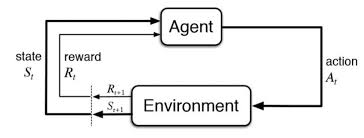

## 🕹️ Play Connect-4!

Before we dive into the technical details, get a feel for the game first.

The widget below lets you play a round against a **BitBully** agent (minimax, 4-ply search). You play as **Yellow** — click a column to drop your token.

> **Tip:** Try to win — it's harder than it looks!

In [ ]:
%matplotlib ipympl
from bitbully import BitBully
from bitbully.gui_c4 import GuiC4

# Human (Yellow) vs BitBully 4-ply (Red)
agents = {
    2: BitBully(opening_book=None, tie_break="center", max_depth=4),
}

c4gui = GuiC4(agents=agents, autoplay=True)
display(c4gui.get_widget())

## 🌍 1. Environment

The **environment** is the Connect-4 game itself. It is fully deterministic: given a state and an action, the next state is uniquely determined — no stochasticity (unlike, e.g., Backgammon or card games).

The environment is implemented as `BoardBatch` — a vectorized, PyTorch-native board representation that can simulate **thousands of games in parallel** on CPU or GPU.

```
┌─────────────────────────────────────────────────────────────┐
│  BoardBatch (batch of B games)                              │
│                                                             │
│   all_tokens    : [B] int64  — every piece on the board     │
│   active_tokens : [B] int64  — only the current player's    │
│   moves_left    : [B] int16  — tokens remaining (max 42)    │
└─────────────────────────────────────────────────────────────┘
```

The opponent's tokens are never stored explicitly — they are derived on-the-fly as:

$$\text{opponent} = \texttt{active\_tokens} \oplus \texttt{all\_tokens}$$

### 🔲 1.1 Bitboards

Each board position is encoded as a **single 64-bit integer**. The 7 columns each occupy 9 bits (6 playable rows + 3 sentinel bits):

```
Bit indices in a uint64 (9 bits per column, 7 columns):

         C0    C1    C2    C3    C4    C5    C6
       ┌─────┬─────┬─────┬─────┬─────┬─────┬─────┐
  S2   │  8  │ 17  │ 26  │ 35  │ 44  │ 53  │ 62  │  ← sentinel
  S1   │  7  │ 16  │ 25  │ 34  │ 43  │ 52  │ 61  │  ← sentinel
  S0   │  6  │ 15  │ 24  │ 33  │ 42  │ 51  │ 60  │  ← sentinel
       ├─────┼─────┼─────┼─────┼─────┼─────┼─────┤
  R5   │  5  │ 14  │ 23  │ 32  │ 41  │ 50  │ 59  │  ← top row
  R4   │  4  │ 13  │ 22  │ 31  │ 40  │ 49  │ 58  │
  R3   │  3  │ 12  │ 21  │ 30  │ 39  │ 48  │ 57  │
  R2   │  2  │ 11  │ 20  │ 29  │ 38  │ 47  │ 56  │
  R1   │  1  │ 10  │ 19  │ 28  │ 37  │ 46  │ 55  │
  R0   │  0  │  9  │ 18  │ 27  │ 36  │ 45  │ 54  │  ← bottom row
       └─────┴─────┴─────┴─────┴─────┴─────┴─────┘
```

**Why sentinels?** Legal move generation uses an addition trick. Adding `BB_BOTTOM_ROW` to `all_tokens` propagates carry bits upward through a column. The 3 sentinel bits absorb carry from a full column, preventing it from overflowing into the next column.

$$\text{legal\_moves} = (\texttt{all\_tokens} + \texttt{BB\_BOTTOM\_ROW}) \mathbin{\&} \texttt{BB\_ALL\_LEGAL}$$

In [ ]:
import sys, os

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))

import torch
from techdays26.torch_board import BoardBatch

# Create a batch of 1 empty board
board = BoardBatch.empty(1, device="cpu")

print("=== Empty board ===")
print(
    f"  all_tokens    = {int(board.all_tokens[0]):#066b}  ({int(board.all_tokens[0])})"
)
print(
    f"  active_tokens = {int(board.active_tokens[0]):#066b}  ({int(board.active_tokens[0])})"
)
print(f"  moves_left    = {int(board.moves_left[0])}")

# Drop Yellow's token into column 3 (center, bottom row → bit 27)
board.play_columns(torch.tensor([3]))

print("\n=== After Yellow plays column 3 ===")
print(f"  all_tokens    = {int(board.all_tokens[0]):#066b}")
print(f"  active_tokens = {int(board.active_tokens[0]):#066b}")
print(f"  moves_left    = {int(board.moves_left[0])}")

bit27_set = bool((int(board.all_tokens[0]) >> 27) & 1)
print(f"\n  Bit 27 (col 3, row 0) set in all_tokens? {bit27_set}  ✓")
print(f"  Active player now: {int(board.active_player()[0])}  (1=Yellow, 2=Red)")

### ⚙️ 1.2 Basic Operations

Three fundamental operations drive the game loop:

#### 🪨 Set stones — `play_columns` / `play_masks`

Placing a token uses the same carry-propagation trick as legal move generation.  
`play_columns(cols)` finds the lowest empty bit in the chosen column and sets it in `all_tokens`.  
`play_masks(mv)` accepts a one-hot bitboard directly (used during tree search for speed).

In [ ]:
# ── Raw bitwise: place a token using the carry trick ─────────────────────────
# Layout: 9 bits per column (6 playable rows + sentinel bits above).
# Bit index for column c, row r  →  c * 9 + r
#
# To find the next empty row in column c, we exploit integer carry:
#   landing = (all_tokens + col_bottom_bit) & col_row_mask
# The +1 carry propagates past all filled rows and lands on the first empty bit.

COL_BITS = 9
all_tokens = 0

col = 3
col_bottom = 1 << (col * COL_BITS)  # lowest bit of column 3  =  bit 27
col_mask = 0b111111 << (col * COL_BITS)  # 6-row mask for column 3

print("Placing 3 tokens in column 3 one at a time:")
for i in range(3):
    landing = (all_tokens + col_bottom) & col_mask  # carry trick
    all_tokens |= landing
    bit_idx = landing.bit_length() - 1
    print(
        f"  Token {i + 1}: set bit {bit_idx}  →  col {col}, row {bit_idx - col * COL_BITS}"
    )

print(f"\nall_tokens (bits 27-35): {(all_tokens >> 27) & 0x1FF:09b}  (9 bits of col 3)")

# ── BoardBatch equivalent ─────────────────────────────────────────────────────
import torch
from techdays26.torch_board import BoardBatch

board = BoardBatch.empty(1)
for _ in range(3):
    board.play_columns(torch.tensor([3]))

board_bits = (int(board.all_tokens[0]) >> 27) & 0x1FF
print(f"board.all_tokens col 3:  {board_bits:09b}")
print(f"Match: {all_tokens == int(board.all_tokens[0])}")

#### 🔄 Switch players — a single XOR

After every move `play_columns` / `play_masks` calls:

```python
active_tokens ^= all_tokens
```

This is a single XOR instruction. Because `all_tokens` now includes the token just placed, XOR-ing with the *previous* `active_tokens` yields the **opponent's** pieces — which become the new `active_tokens` for the next turn. No copy, no extra field.

In [ ]:
# ── Raw bitwise: XOR player swap ──────────────────────────────────────────────
# We track TWO bitboards:
#   all_tokens    — every token on the board (both colours)
#   active_tokens — only the current player's tokens
#
# After placing a token:
#   all_tokens    |= landing          # add the new token
#   active_tokens ^= all_tokens       # XOR flips to opponent's pieces
#
# Why does XOR work?
#   Before the move: active = Yellow's bits, all = Yellow|Red bits
#   After  the move: all gains Yellow's new bit
#   XOR(old_active, new_all) = bits that are in one but not both
#                             = Red's bits  ✓

all_tokens = 0
active_tokens = 0  # Yellow starts with 0 tokens

print(f"{'Turn':>4}  {'Player':>6}  active_tokens col3 (bits 27-35)")
print("-" * 52)

moves = [3, 3, 3, 3]  # both players keep dropping in col 3
COL_BITS = 9
col, col_bottom = 3, 1 << 27
col_mask = 0b111111 << 27

for turn, _ in enumerate(moves):
    player = "Yellow" if turn % 2 == 0 else "Red"
    snippet = (active_tokens >> 27) & 0x1FF
    print(f"  {turn:2d}    {player:>6}  {snippet:09b}")

    landing = (all_tokens + col_bottom) & col_mask
    all_tokens |= landing
    active_tokens ^= all_tokens  # single XOR — now opponent's pieces

# ── BoardBatch equivalent ─────────────────────────────────────────────────────
board = BoardBatch.empty(1)
for col in moves:
    board.play_columns(torch.tensor([col]))

y_bits = (int(board.active_tokens[0]) >> 27) & 0x1FF
r_bits = ((int(board.all_tokens[0]) ^ int(board.active_tokens[0])) >> 27) & 0x1FF
print(f"\nBoardBatch col-3 slice after 4 moves:")
print(f"  Yellow (active_tokens): {y_bits:09b}")
print(f"  Red    (all ^ active):  {r_bits:09b}")

#### 🏆 Detect wins — shift-AND in 4 directions

`has_win()` checks whether the player who just moved has four-in-a-row. It uses the **shift-AND** technique: shift a bitboard by the stride for a given direction, AND with the original. If two such shifted-AND results overlap, four consecutive bits are set.

| Direction  | Bit stride |
|------------|-----------|
| Horizontal | 9 (column offset) |
| Vertical   | 1 |
| Diagonal ↗ | 10 (col + 1) |
| Diagonal ↘ | 8  (col − 1) |

```python
# Vertical example (stride = 1):
x = y & (y << 2)       # pairs of 2 in the same column
win |= (x & (x << 1))  # 4 in a row
```

The entire win check runs in **O(1)** — no loop over cells.

In [ ]:
# ── Raw bitwise: shift-AND win detection ──────────────────────────────────────
# For any direction with bit-stride s:
#   pairs = y & (y >> s)          # bit i is set  ↔  tokens at i AND i+s
#   win   = pairs & (pairs >> 2s) # bit i is set  ↔  tokens at i, i+s, i+2s, i+3s
#
# Four directions:
STRIDES = {"horizontal": 9, "vertical": 1, "diagonal ↗": 10, "diagonal ↘": 8}

# Yellow fills the bottom row of columns 0-3: bits 0, 9, 18, 27
yellow = (1 << 0) | (1 << 9) | (1 << 18) | (1 << 27)

print("Win-check for Yellow filling cols 0-3 (bottom row):")
print(f"  yellow = {yellow:064b}\n")

for name, s in STRIDES.items():
    pairs = yellow & (yellow >> s)
    win = pairs & (pairs >> (2 * s))
    print(f"  {name:14s} (stride={s:2d}): pairs={pairs:064b}  win={bool(win)}")

# Zoom in on the horizontal case (stride 9)
print("\nHorizontal zoom (bits 0-35 only):")
s = 9
pairs = yellow & (yellow >> s)
win = pairs & (pairs >> (2 * s))
print(f"  yellow = {yellow & 0xFFFFFFFFF:036b}")
print(f"  pairs  = {pairs & 0xFFFFFFFFF:036b}   (y & y>>9)")
print(f"  win    = {win & 0xFFFFFFFFF:036b}   (pairs & pairs>>18)")

# ── BoardBatch equivalent ─────────────────────────────────────────────────────
board = BoardBatch.empty(1)
move_seq = [0, 6, 1, 6, 2, 6, 3]  # Yellow wins col 0-3; Red parks in col 6
for i, col in enumerate(move_seq):
    board.play_columns(torch.tensor([col]))
    if i % 2 == 0:  # Yellow just moved
        win = bool(board.has_win()[0])
        print(
            f"\nAfter Yellow → col {col}: has_win={win}  reward={float(board.reward()[0]):.1f}"
        )

### 👁️ 1.3 Visualization Widget

The `BitboardVisualizer` renders the raw bitboard as an interactive Connect-4 board. Use it to build positions manually and inspect overlays (legal moves, winning threats, bit index map, win-check steps).

> See **[`lab2/bitboard_demo.ipynb`](bitboard_demo.ipynb)** for a full walkthrough of all overlays.

In [ ]:
%matplotlib ipympl
from techdays26.gui_bitboard import BitboardVisualizer

# Launch an interactive board — click columns to play, select overlay from the dropdown
vis = BitboardVisualizer()
vis.show()

### ⚡ 1.4 Advantages of the Bitboard Representation

| Property | Benefit |
|---|---|
| **Compact** | Entire game state = 2 × int64 + 1 × int16 — fits in a few registers |
| **Vectorized** | `BoardBatch` stores a whole batch `[B]` of boards as three flat tensors; all operations are elementwise PyTorch ops |
| **GPU-ready** | One `.to("cuda")` call moves the entire batch; every bitwise op runs as a fused GPU kernel with uniform control flow across all boards |
| **O(1) win check** | Four shift-AND operations cover all four directions simultaneously |
| **No copies for player swap** | `active_tokens ^= all_tokens` — one instruction, in-place |
| **Scalable** | Training uses `B = 20 000` parallel games; the bitboard layout makes this practical |


## 🔭 Future Work
- Deeper Networks?
- CNNs?
- Own Step-size Adaptation?
- real backward view of eligibility traces